# Détection des déchets de plage - Colab Demo

Projet éducatif AI for Good avec données imaginées.

Objectif : classifier des observations de plage en catégories de déchets ou sable propre.

In [ ]:
!pip install pandas numpy scikit-learn matplotlib joblib -q

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('outputs', exist_ok=True)

## 1. Génération de données fictives

In [2]:
np.random.seed(42)
classes = {
    'plastic_bottle': [(80,250),(0.45,0.85),(0.30,0.70),(0.2,0.9),(0.15,0.55),(0.55,0.95),(0,25),(0.25,0.65)],
    'food_wrapper': [(25,150),(0.55,1.0),(0.45,0.95),(0.1,0.6),(0.45,0.95),(0.30,0.85),(0,40),(0.10,0.45)],
    'fishing_net': [(200,900),(0.20,0.60),(0.65,1.0),(0.45,1.0),(0.75,1.0),(0.65,1.0),(0,15),(0.05,0.35)],
    'glass_bottle': [(70,260),(0.65,1.0),(0.25,0.65),(0.30,0.90),(0.10,0.40),(0.55,0.95),(0,35),(0.30,0.75)],
    'metal_can': [(40,160),(0.70,1.0),(0.35,0.80),(0.10,0.45),(0.15,0.45),(0.35,0.70),(0,30),(0.55,0.95)],
    'organic_waste': [(20,300),(0.20,0.65),(0.15,0.55),(0.15,0.75),(0.50,1.0),(0.20,0.80),(0,50),(0.20,0.80)],
    'clean_sand': [(0,30),(0.55,0.95),(0.00,0.25),(0.05,0.25),(0.10,0.35),(0.00,0.40),(0,60),(0.20,0.70)]
}
features = ['size_cm2','brightness','edge_density','blue_green_ratio','texture_score','elongation','near_water_m','roundness']
rows = []
for label, ranges in classes.items():
    for _ in range(180):
        values = [np.random.uniform(a,b) for a,b in ranges]
        row = dict(zip(features, values))
        row['class'] = label
        row['is_waste'] = 0 if label == 'clean_sand' else 1
        row['risk_score'] = min(1.0, max(0.0, row['size_cm2']/900 + row['edge_density']*0.25 + row['texture_score']*0.25))
        rows.append(row)
df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)
df.to_csv('data/synthetic_beach_waste.csv', index=False)
df.head()

,size_cm2,brightness,edge_density,blue_green_ratio,texture_score,elongation,near_water_m,roundness,class,is_waste,risk_score
0,165.580936,0.726158,0.315725,0.759587,0.401160,0.582704,21.839466,0.618349,plastic_bottle,1,0.363200
1,105.515780,0.270947,0.219604,0.606456,0.507919,0.534686,18.973069,0.503930,organic_waste,1,0.299121
2,147.745805,0.696340,0.554037,0.231713,0.299845,0.800344,12.578406,0.592596,plastic_bottle,1,0.377633
3,153.516959,0.828661,0.353517,0.489874,0.126090,0.671288,33.829545,0.725118,glass_bottle,1,0.290476
4,451.035107,0.564536,0.657327,0.623675,0.764220,0.918285,10.531612,0.149406,fishing_net,1,0.856537


## 2. Visualisation rapide

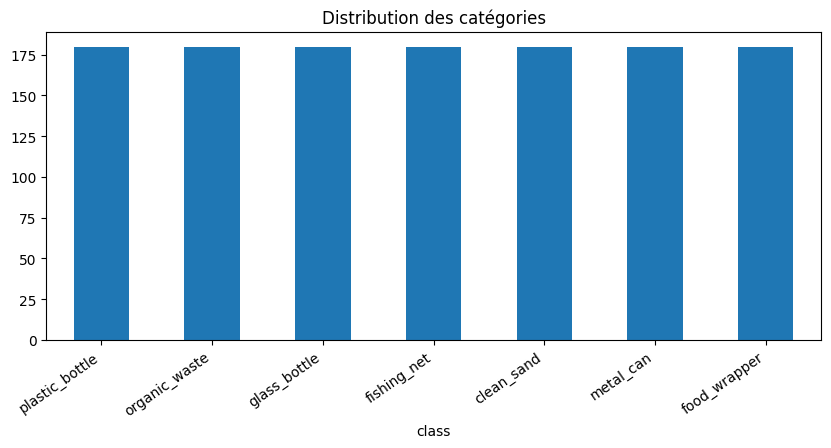

In [3]:
df['class'].value_counts().plot(kind='bar', figsize=(10,4))
plt.title('Distribution des catégories')
plt.xticks(rotation=35, ha='right')
plt.show()

## 3. Entraînement du modèle

In [ ]:
FEATURES = features + ['risk_score']
X = df[FEATURES]
y = df['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=250, random_state=42, class_weight='balanced'))
])
model.fit(X_train, y_train)
preds = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, preds))
print(classification_report(y_test, preds))
joblib.dump(model, 'models/beach_waste_classifier.joblib')

## 4. Matrice de confusion

In [4]:
ConfusionMatrixDisplay.from_predictions(y_test, preds, xticks_rotation=45)
plt.title('Matrice de confusion')
plt.show()

NameError: name 'y_test' is not defined

## 5. Prédiction sur un exemple imaginé

In [ ]:
sample = pd.DataFrame([{
    'size_cm2': 180,
    'brightness': 0.72,
    'edge_density': 0.50,
    'blue_green_ratio': 0.60,
    'texture_score': 0.30,
    'elongation': 0.80,
    'near_water_m': 8,
    'roundness': 0.45,
    'risk_score': 0.55
}])
prediction = model.predict(sample)[0]
print('Déchet détecté :', prediction)
probas = model.predict_proba(sample)[0]
pd.DataFrame({'classe': model.named_steps['classifier'].classes_, 'probabilité': probas}).sort_values('probabilité', ascending=False)